Question 3

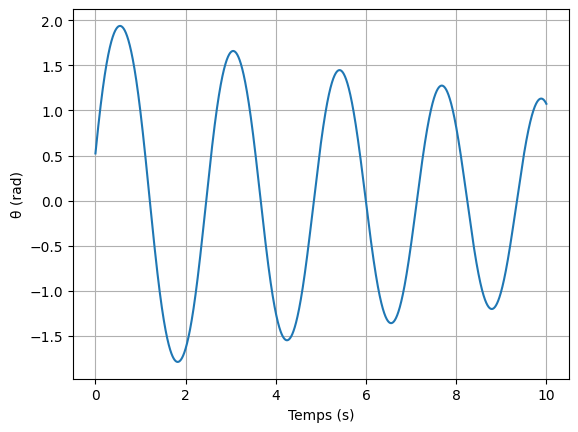

Pour dt = 0.01  angle final (en rad) = 1.0742497173075356
Pour dt = 0.005  angle final (en rad) = 1.074093244715028
Pour dt = 0.0025  angle final (en rad) = 1.0740541409251028
Pour dt = 0.00125  angle final (en rad) = 1.0740443657809393
Pour dt = 0.000625  angle final (en rad) = 1.0740419224067073


In [33]:
# PHS3903 - Projet de simulation
# Mini-devoir 1

import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from scipy import stats

# Paramètres physiques du problème
g = 9.81     # Champ gravitationnel (m²/s)
m = 1.000    # Masse du pendule (kg)
L = 1.000    # Longueur du câble (m)
beta = 0.1   # Constante d'amortissement (1/s)

# Conditions initiales
theta0 = np.pi/6     # Position initiale (rad)
omega0 = 5           # Vitesse inititale (rad/s)

# Paramètres généraux de simulation
tf = 10       # Temps final (s)
dt0 = 0.01  # Pas de temps le plus élevé (s)

# Boucle sur le nombre de simulations
K = 5                                       # Nombre de simulations
dt_val = [dt0, dt0/2, dt0/4, dt0/8, dt0/16] # Vecteur des pas de temps pour chaque simulation
thetaf = np.zeros(K)                        # Vecteur des positions finales pour chaque simulation

for k in range(0,K):
# Paramètres spécifiques de la simulation
    dt = dt_val[k]               # Pas de temps de la simulation
    N = np.round(int(tf/dt))               # Nombre d'itérations

# Initialisation
    t = np.arange(0, tf + dt, dt)  # Vecteur des valeurs t_n
    theta = np.zeros(N + 1)        # Vecteur des valeurs theta_n
    theta[0] = theta0
 
    theta[1] = theta0 + (1 - beta*dt/2)*omega0*dt - (g/(2*L))*dt**2*np.sin(theta0)

# Exécution
    for n in range(1, N):
        theta[n+1] = (
            4*theta[n]
            - (2 - beta*dt)*theta[n-1]
            - (2*g/L)*dt**2*np.sin(theta[n])
        ) / (2 + beta*dt)

    thetaf[k] = theta[-1]  # Position au temps final tf


plt.plot(t, theta)
plt.xlabel("Temps (s)")
plt.ylabel("θ (rad)")
plt.grid()
plt.show()


for k in range(K):
    print("Pour dt =", dt_val[k], " angle final (en rad) =", thetaf[k])


Question 4

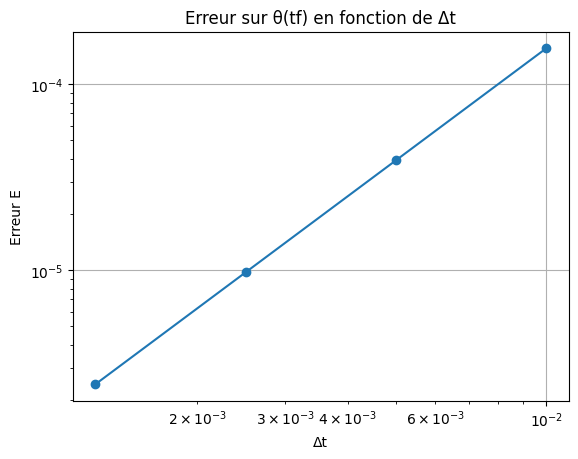

Ordre = 2.0002792522211448


In [34]:

E = np.zeros(K-1)

for k in range(K-1):
    E[k] = abs(thetaf[k] - thetaf[k+1])

dt_erreur = dt_val[:-1]


plt.figure()
plt.loglog(dt_erreur, E, 'o-')
plt.xlabel("Δt")
plt.ylabel("Erreur E")
plt.title("Erreur sur θ(tf) en fonction de Δt")
plt.grid()
plt.show()


log_dt = np.log(dt_erreur)
log_E = np.log(E)

p, _ = np.polyfit(log_dt, log_E, 1)

print("Ordre =", p)